# Segmentation-Based Termination Comparison

This notebook visualizes and compares termination conditions between two images using methods from `gsam2_terminator.py`.

## What it does:
1. **Segments objects** using Grounded SAM2 (Segment Anything Model 2 + Grounding DINO)
2. **Compares masks** using two metrics:
   - **Mask Size**: Compares the number of pixels in segmentation masks
   - **SSIM**: Compares structural similarity of segmented object regions
3. **Visualizes** the segmentation results, masks, and differences

## Usage:
1. Update `text_prompt` in Cell 2 to match your target object (e.g., "cube.", "cat.", "bottle.")
2. Update `image1_path` and `image2_path` in Cell 3 to point to your images
3. Run all cells sequentially

## Requirements:
- Grounded SAM2 models must be installed (see `lib/Grounded-SAM-2/`)
- SAM2 checkpoint: `checkpoints/sam2.1_hiera_large.pt`
- Requires CUDA for best performance (CPU will be slow)

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# Add parent directory to path to import gsam2_terminator
sys.path.insert(0, str(Path.cwd().parent))
from gsam2_terminator import SegmentationTerminator

In [ ]:
text_prompt = "giraffe."
# text_prompt = "cat."

print("Initializing SegmentationTerminator...")
terminator = SegmentationTerminator(
    text_prompt=text_prompt,
    similarity_threshold=0.15,
    box_threshold=0.35,
    text_threshold=0.25
)
print("Initialization complete!")

Initializing SegmentationTerminator...
Initializing SegmentationTerminator on cuda...
Loading SAM2 from /home/khw/IBVS-interbotix/lib/Grounded-SAM-2/checkpoints/sam2.1_hiera_large.pt...
Using config: configs/sam2.1/sam2.1_hiera_l.yaml
Loading Grounding DINO: IDEA-Research/grounding-dino-tiny...


The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 990/990 [00:00<00:00, 2983.45it/s, Materializing param=model.text_projection.weight]                                                                           


SegmentationTerminator initialized successfully!
Initialization complete!


In [4]:
# Specify the two images to compare
# image1_path = "../img/rgbimage_0.png"  # Target/reference image
# image2_path = "../img/rgbimage_39.png"  # Current/comparison image

image1_path = "/home/khw/IBVS-interbotix/src/straight_line_img/frame_000.png"  # Target/reference image
image2_path = "/home/khw/IBVS-interbotix/src/straight_line_img/frame_025.png"  # Current/comparison image

# Load images for display
image1 = Image.open(image1_path).convert("RGB")
image2 = Image.open(image2_path).convert("RGB")

print(f"Image 1: {image1_path} - Size: {image1.size}")
print(f"Image 2: {image2_path} - Size: {image2.size}")

image1 = np.array(image1)
image2 = np.array(image2)

Image 1: /home/khw/IBVS-interbotix/src/straight_line_img/frame_000.png - Size: (640, 480)
Image 2: /home/khw/IBVS-interbotix/src/straight_line_img/frame_025.png - Size: (640, 480)


In [5]:
terminator.get_segmented_object(image1_path)

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  84,   0,   0,   0,  76,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0, 122, 124, 123, 124, 126, 128, 125,  89, 110, 125,
         96,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,  88, 123, 122, 123, 123, 122,  90, 126, 125, 125, 116,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,  99, 108, 113, 124, 124, 122, 110, 111, 123, 123, 113,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,  71, 120, 123, 124, 123, 123, 124, 123, 123, 106,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
      

In [6]:
# Get segmentation masks and metrics for both images
print("Computing masks and metrics...")

# Get mask sizes
mask_size1 = terminator.get_mask_size(image1_path)
mask_size2 = terminator.get_mask_size(image2_path)

# Calculate relative difference
if mask_size1 > 0:
    relative_diff = abs(mask_size2 - mask_size1) / mask_size1
else:
    relative_diff = float('inf')

# Get segmented objects for visualization
segmented_obj1 = terminator.get_segmented_object(image1_path)
segmented_obj2 = terminator.get_segmented_object(image2_path)

# Compute SSIM if both segmentations succeeded
if segmented_obj1 is not None and segmented_obj2 is not None:
    # Set target for SSIM computation
    terminator.set_target_image(image1_path)
    ssim_score = terminator.compute_ssim(image2_path)
else:
    ssim_score = 0.0

print(f"\\nMask size (Image 1): {mask_size1:.0f} pixels")
print(f"Mask size (Image 2): {mask_size2:.0f} pixels")
print(f"Relative difference: {relative_diff:.2%}")
print(f"SSIM score: {ssim_score:.4f}")
print(f"\\nWould terminate (mask_size mode, threshold=15%): {relative_diff < 0.15}")
print(f"Would terminate (SSIM mode, threshold=0.85): {ssim_score >= 0.85}")

Computing masks and metrics...
Segmenting target object from /home/khw/IBVS-interbotix/src/straight_line_img/frame_000.png...
Target object segmented: (31, 25)
\nMask size (Image 1): 263 pixels
Mask size (Image 2): 1314 pixels
Relative difference: 399.62%
SSIM score: 0.7950
\nWould terminate (mask_size mode, threshold=15%): False
Would terminate (SSIM mode, threshold=0.85): False


In [7]:
# Helper function to get full masks (not just cropped objects)
def get_full_mask(terminator, image_path):
    """Get the full-size segmentation mask for visualization."""
    from PIL import Image
    
    # Load image
    if isinstance(image_path, (str, Path)):
        image = Image.open(image_path).convert("RGB")
        image_np = np.array(image)
    else:
        image = image_path
        image_np = np.array(image)
    
    # Set image for SAM2
    terminator.sam2_predictor.set_image(image_np)
    
    # Run Grounding DINO detection
    inputs = terminator.processor(images=image, text=terminator.text_prompt, return_tensors="pt").to(terminator.device)
    
    import torch
    with torch.no_grad():
        outputs = terminator.grounding_model(**inputs)
    
    results = terminator.processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=terminator.box_threshold,
        text_threshold=terminator.text_threshold,
        target_sizes=[image.size[::-1]]
    )
    
    # Check if any objects were detected
    if len(results) == 0 or len(results[0]["boxes"]) == 0:
        return None, None
    
    # Get bounding boxes for SAM2
    input_boxes = results[0]["boxes"].cpu().numpy()
    
    # Get segmentation masks
    masks, scores, logits = terminator.sam2_predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_boxes,
        multimask_output=False,
    )
    
    # Convert shape to (n, H, W) if needed
    if masks.ndim == 4:
        masks = masks.squeeze(1)
    
    # Combine all masks
    combined_mask = np.any(masks, axis=0) if len(masks) > 0 else masks[0]
    
    return combined_mask, input_boxes

# Get full masks for visualization
mask1, boxes1 = get_full_mask(terminator, image1_path)
mask2, boxes2 = get_full_mask(terminator, image2_path)

print("Masks extracted successfully!")

Masks extracted successfully!


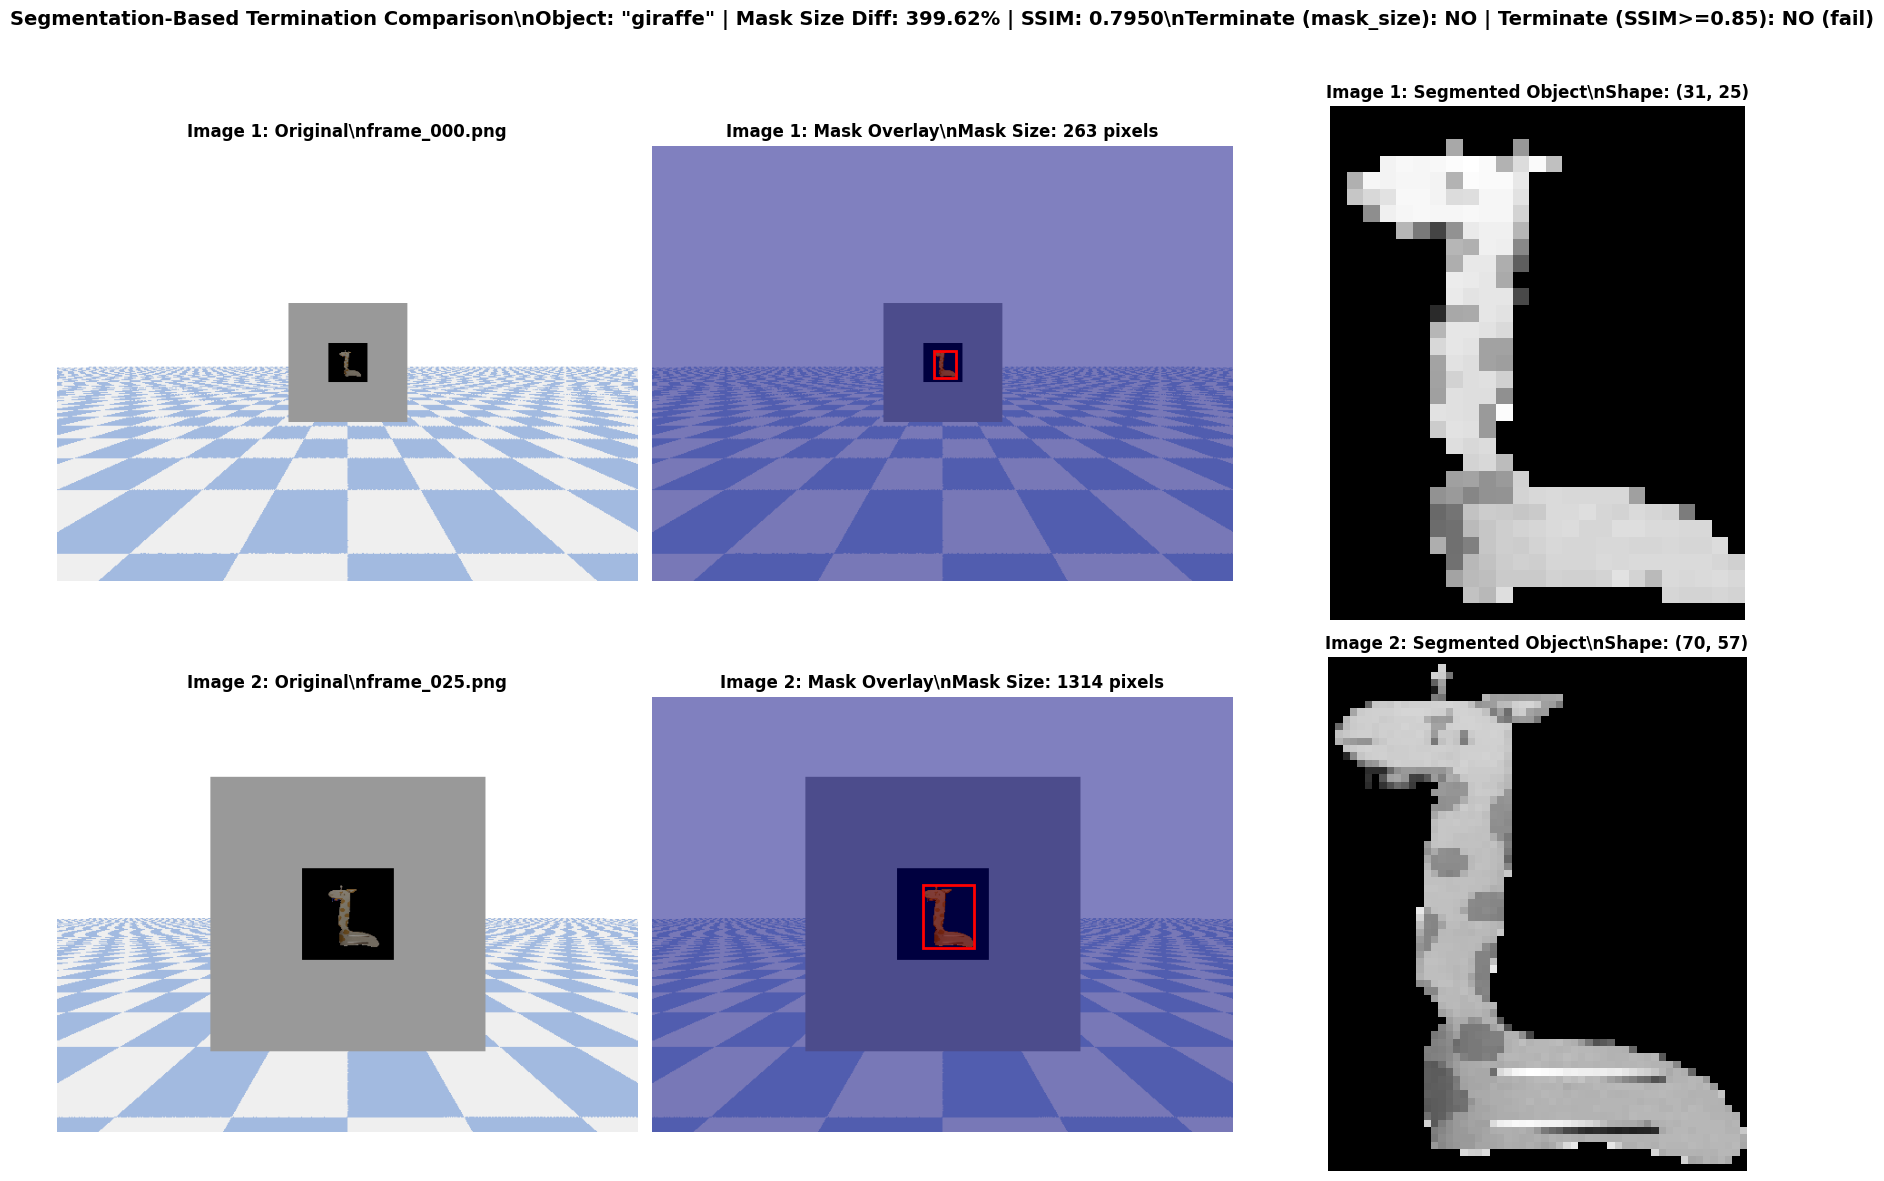

In [8]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: Image 1 (Target/Reference)
# Original image
axes[0, 0].imshow(image1)
axes[0, 0].set_title(f'Image 1: Original\\n{Path(image1_path).name}', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Segmentation mask
if mask1 is not None:
    axes[0, 1].imshow(image1)
    axes[0, 1].imshow(mask1, alpha=0.5, cmap='jet')
    # Draw bounding boxes
    if boxes1 is not None:
        for box in boxes1:
            x1, y1, x2, y2 = box
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                fill=False, edgecolor='red', linewidth=2)
            axes[0, 1].add_patch(rect)
    axes[0, 1].set_title(f'Image 1: Mask Overlay\\nMask Size: {mask_size1:.0f} pixels', 
                         fontsize=12, fontweight='bold')
else:
    axes[0, 1].text(0.5, 0.5, 'No mask detected', 
                    ha='center', va='center', transform=axes[0, 1].transAxes)
    axes[0, 1].set_title('Image 1: Mask Overlay', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

# Segmented object
if segmented_obj1 is not None:
    axes[0, 2].imshow(segmented_obj1, cmap='gray')
    axes[0, 2].set_title(f'Image 1: Segmented Object\\nShape: {segmented_obj1.shape}', 
                         fontsize=12, fontweight='bold')
else:
    axes[0, 2].text(0.5, 0.5, 'No object segmented', 
                    ha='center', va='center', transform=axes[0, 2].transAxes)
    axes[0, 2].set_title('Image 1: Segmented Object', fontsize=12, fontweight='bold')
axes[0, 2].axis('off')

# Row 2: Image 2 (Current/Comparison)
# Original image
axes[1, 0].imshow(image2)
axes[1, 0].set_title(f'Image 2: Original\\n{Path(image2_path).name}', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

# Segmentation mask
if mask2 is not None:
    axes[1, 1].imshow(image2)
    axes[1, 1].imshow(mask2, alpha=0.5, cmap='jet')
    # Draw bounding boxes
    if boxes2 is not None:
        for box in boxes2:
            x1, y1, x2, y2 = box
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                                fill=False, edgecolor='red', linewidth=2)
            axes[1, 1].add_patch(rect)
    axes[1, 1].set_title(f'Image 2: Mask Overlay\\nMask Size: {mask_size2:.0f} pixels', 
                         fontsize=12, fontweight='bold')
else:
    axes[1, 1].text(0.5, 0.5, 'No mask detected', 
                    ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Image 2: Mask Overlay', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

# Segmented object
if segmented_obj2 is not None:
    axes[1, 2].imshow(segmented_obj2, cmap='gray')
    axes[1, 2].set_title(f'Image 2: Segmented Object\\nShape: {segmented_obj2.shape}', 
                         fontsize=12, fontweight='bold')
else:
    axes[1, 2].text(0.5, 0.5, 'No object segmented', 
                    ha='center', va='center', transform=axes[1, 2].transAxes)
    axes[1, 2].set_title('Image 2: Segmented Object', fontsize=12, fontweight='bold')
axes[1, 2].axis('off')

# Add overall title with comparison metrics
terminate_mask = 'YES' if relative_diff < 0.15 else 'NO'
terminate_ssim = 'YES (pass)' if ssim_score >= 0.85 else 'NO (fail)'
title_text = (
    f'Segmentation-Based Termination Comparison\\n'
    f'Object: \"{text_prompt[:-1]}\" | '
    f'Mask Size Diff: {relative_diff:.2%} | '
    f'SSIM: {ssim_score:.4f}\\n'
    f'Terminate (mask_size): {terminate_mask} | '
    f'Terminate (SSIM>=0.85): {terminate_ssim}'
)
fig.suptitle(title_text, fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

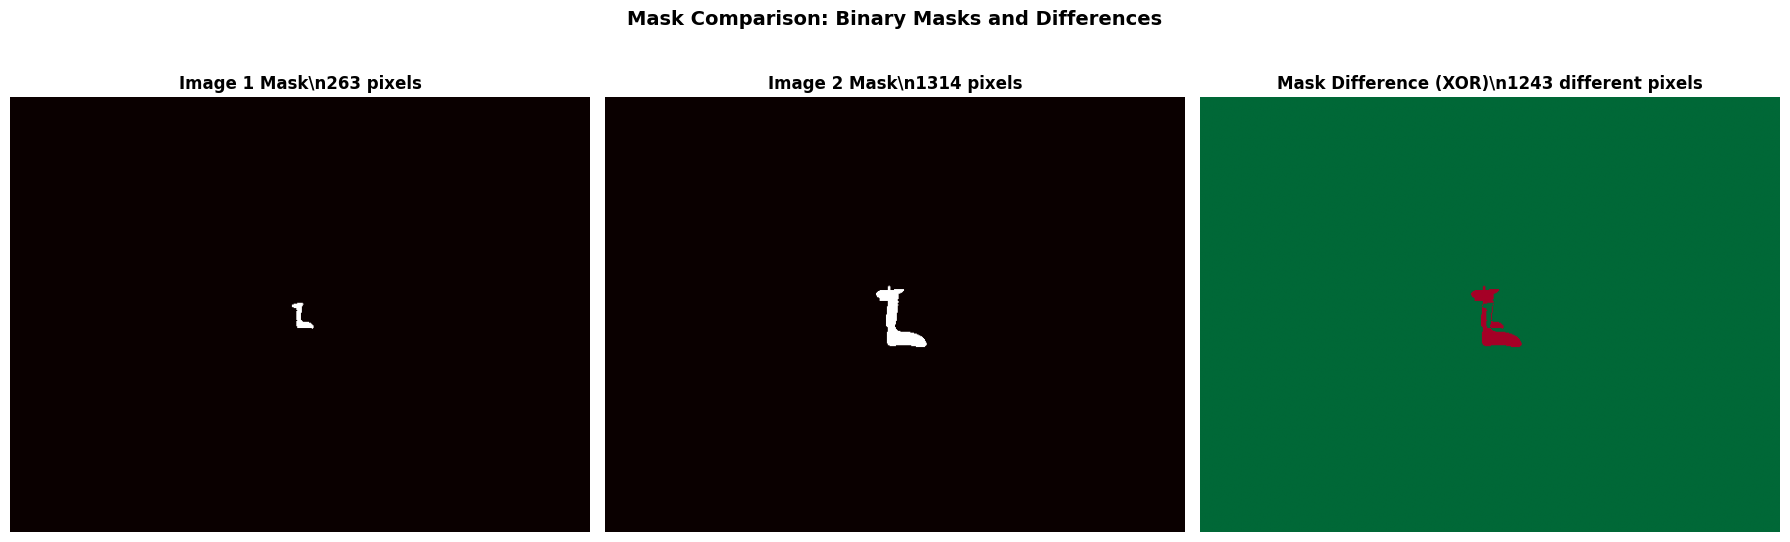

In [9]:
# Additional visualization: Mask difference heatmap
if mask1 is not None and mask2 is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Show mask 1
    axes[0].imshow(mask1, cmap='hot')
    axes[0].set_title(f'Image 1 Mask\\n{mask_size1:.0f} pixels', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Show mask 2
    axes[1].imshow(mask2, cmap='hot')
    axes[1].set_title(f'Image 2 Mask\\n{mask_size2:.0f} pixels', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # Show difference (XOR - areas that differ)
    mask_diff = np.logical_xor(mask1, mask2)
    axes[2].imshow(mask_diff, cmap='RdYlGn_r')
    diff_pixels = np.sum(mask_diff)
    axes[2].set_title(f'Mask Difference (XOR)\\n{diff_pixels:.0f} different pixels', 
                     fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    fig.suptitle('Mask Comparison: Binary Masks and Differences', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Cannot create mask difference visualization - one or both masks are None")

In [10]:
!pip install pandas

In [11]:
# Summary table of metrics
import pandas as pd

# Prepare shape strings
shape1_str = str(segmented_obj1.shape) if segmented_obj1 is not None else "N/A"
shape2_str = str(segmented_obj2.shape) if segmented_obj2 is not None else "N/A"

# Prepare detection strings
detect1_str = 'Detected' if mask1 is not None else 'Not Detected'
detect2_str = 'Detected' if mask2 is not None else 'Not Detected'

# Prepare termination strings
terminate_mask_str = 'YES (pass)' if relative_diff < 0.15 else 'NO (fail)'
terminate_ssim_str = 'YES (pass)' if ssim_score >= 0.85 else 'NO (fail)'

summary_data = {
    'Metric': [
        'Mask Size (pixels)',
        'Segmented Object Shape',
        'Detection Confidence'
    ],
    'Image 1 (Target)': [
        f'{mask_size1:.0f}',
        shape1_str,
        detect1_str
    ],
    'Image 2 (Current)': [
        f'{mask_size2:.0f}',
        shape2_str,
        detect2_str
    ]
}

comparison_data = {
    'Termination Criterion': [
        'Mask Size Similarity (threshold: 15%)',
        'SSIM on Segmented Objects (threshold: 0.85)'
    ],
    'Value': [
        f'{relative_diff:.2%}',
        f'{ssim_score:.4f}'
    ],
    'Terminate?': [
        terminate_mask_str,
        terminate_ssim_str
    ]
}

print("=" * 80)
print("COMPARISON SUMMARY")
print("=" * 80)
print("\nImage Details:")
print(pd.DataFrame(summary_data).to_string(index=False))
print("\n" + "=" * 80)
print("\nTermination Criteria:")
print(pd.DataFrame(comparison_data).to_string(index=False))
print("=" * 80)

COMPARISON SUMMARY

Image Details:
                Metric Image 1 (Target) Image 2 (Current)
    Mask Size (pixels)              263              1314
Segmented Object Shape         (31, 25)          (70, 57)
  Detection Confidence         Detected          Detected


Termination Criteria:
                      Termination Criterion   Value Terminate?
      Mask Size Similarity (threshold: 15%) 399.62%  NO (fail)
SSIM on Segmented Objects (threshold: 0.85)  0.7950  NO (fail)
